In [2]:
import os 
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image


In [3]:
data_path = '../data'

In [3]:
os.listdir(data_path)

['test', 'train']

In [5]:
import json
from collections import Counter

def Distribution_of_image_size(data_path, split='train', test_folder='Pa7a3Hin-test-public'):
    """EDA kich thuoc anh theo tung split, gom LR/HR va visual cac anh extreme."""
    split = split.lower()
    split_path = os.path.join(data_path, test_folder if split == 'test' else split)

    if not os.path.exists(split_path):
        raise FileNotFoundError(f'Not found: {split_path}')

    image_exts = ('.png', '.jpg', '.jpeg', '.bmp', '.webp')
    lr_files, hr_files = [], []

    for root, _, files in os.walk(split_path):
        for fname in files:
            low = fname.lower()
            if not low.endswith(image_exts):
                continue
            fpath = os.path.join(root, fname)
            if low.startswith('lr-'):
                lr_files.append(fpath)
            elif low.startswith('hr-'):
                hr_files.append(fpath)

    print(f'[{split}] root: {split_path}')
    print(f'Number of LR images: {len(lr_files)}')
    print(f'Number of HR images: {len(hr_files)}')

    def collect_sizes(paths):
        records = []
        for p in paths:
            with Image.open(p) as img:
                w, h = img.size
            records.append({'path': p, 'width': w, 'height': h})
        return records

    def get_extreme_samples(records):
        return {
            'max_w': max(records, key=lambda x: x['width']),
            'min_w': min(records, key=lambda x: x['width']),
            'max_h': max(records, key=lambda x: x['height']),
            'min_h': min(records, key=lambda x: x['height']),
        }

    def print_extreme_samples(extreme, tag):
        print(
            f'[{tag}] Max width sample : {extreme["max_w"]["width"]} x {extreme["max_w"]["height"]} | {extreme["max_w"]["path"]}'
        )
        print(
            f'[{tag}] Min width sample : {extreme["min_w"]["width"]} x {extreme["min_w"]["height"]} | {extreme["min_w"]["path"]}'
        )
        print(
            f'[{tag}] Max height sample: {extreme["max_h"]["width"]} x {extreme["max_h"]["height"]} | {extreme["max_h"]["path"]}'
        )
        print(
            f'[{tag}] Min height sample: {extreme["min_h"]["width"]} x {extreme["min_h"]["height"]} | {extreme["min_h"]["path"]}'
        )

    def plot_sizes(records, title, color):
        widths = [r['width'] for r in records]
        heights = [r['height'] for r in records]
        plt.figure(figsize=(8, 5))
        plt.scatter(widths, heights, c=color, marker='x', alpha=0.65)
        plt.xlabel('Width')
        plt.ylabel('Height')
        plt.title(title)
        plt.grid(alpha=0.3)
        plt.show()

    def visualize_extreme_images(extreme, tag):
        items = [
            ('Max width', extreme['max_w']),
            ('Min width', extreme['min_w']),
            ('Max height', extreme['max_h']),
            ('Min height', extreme['min_h']),
        ]
        fig, axes = plt.subplots(2, 2, figsize=(12, 10))
        axes = axes.flatten()

        for ax, (name, sample) in zip(axes, items):
            with Image.open(sample['path']) as img:
                rgb_img = img.convert('RGB')
                img_array = np.array(rgb_img)
            ax.imshow(img_array)
            ax.set_title(f"{tag} - {name}: {sample['width']}x{sample['height']}")
            ax.axis('off')

        fig.suptitle(f"{split.upper()} - {tag} extreme samples", fontsize=13)
        plt.tight_layout()
        plt.show()

    lr_records = collect_sizes(lr_files)
    if lr_records:
        lr_extreme = get_extreme_samples(lr_records)
        print_extreme_samples(lr_extreme, 'LR')
        plot_sizes(lr_records, f'{split.upper()} - LR size distribution', 'tab:blue')
        visualize_extreme_images(lr_extreme, 'LR')
    else:
        print('No LR images found for this split.')

    hr_records = collect_sizes(hr_files)
    if hr_records:
        hr_extreme = get_extreme_samples(hr_records)
        print_extreme_samples(hr_extreme, 'HR')
        plot_sizes(hr_records, f'{split.upper()} - HR size distribution', 'tab:orange')
        visualize_extreme_images(hr_extreme, 'HR')
    else:
        print('No HR images found for this split.')


def extract_alnum_char_counter(text):
    """Lay ky tu hop le (a-z, 0-9) va tra ve Counter theo 1 sample."""
    chars = [ch.lower() for ch in str(text) if ch.isalnum()]
    return Counter(chars)


def get_char_counter_per_sample(data_path, split='train', test_folder='Pa7a3Hin-test-public'):
    """
    Doc annotations va tao thong ke ky tu theo tung sample anh.
    Moi sample la 1 anh (LR/HR), gia tri thong ke duoc lay tu plate_text cua annotation.
    """
    split = split.lower()
    split_path = os.path.join(data_path, test_folder if split == 'test' else split)

    if not os.path.exists(split_path):
        raise FileNotFoundError(f'Not found: {split_path}')

    lr_samples, hr_samples = [], []

    for root, _, files in os.walk(split_path):
        for fname in files:
            if fname.lower() != 'annotations.json':
                continue

            ann_path = os.path.join(root, fname)
            try:
                with open(ann_path, 'r', encoding='utf-8') as f:
                    ann = json.load(f)
            except Exception as e:
                print(f'Warning: cannot read annotation {ann_path}: {e}')
                continue

            plate_text = ann.get('plate_text', '')
            char_counter = extract_alnum_char_counter(plate_text)
            corners = ann.get('corners', {})

            for img_name in corners.keys():
                rec = {
                    'image_name': img_name,
                    'plate_text': plate_text,
                    'char_counter': dict(char_counter),
                    'annotation_path': ann_path,
                }
                img_low = img_name.lower()
                if img_low.startswith('lr-'):
                    lr_samples.append(rec)
                elif img_low.startswith('hr-'):
                    hr_samples.append(rec)

    return lr_samples, hr_samples


def summarize_char_counter(samples, tag, split='train'):
    """Tong hop tan suat ky tu tren toan bo sample (theo LR/HR)."""
    if not samples:
        print(f'No character data for {tag}.')
        return Counter()

    total_counter = Counter()
    for s in samples:
        total_counter.update(s['char_counter'])

    print(f'[{split}] {tag} samples: {len(samples)}')
    print(f'[{tag}] total valid chars: {sum(total_counter.values())}')
    print(f'[{tag}] character frequency: {dict(sorted(total_counter.items()))}')

    keys = sorted(total_counter.keys())
    values = [total_counter[k] for k in keys]

    plt.figure(figsize=(10, 4))
    plt.bar(keys, values, color='seagreen', alpha=0.9)
    plt.xlabel('Character')
    plt.ylabel('Frequency')
    plt.title(f'{split.upper()} - {tag} character frequency')
    plt.grid(axis='y', alpha=0.25)
    plt.show()

    return total_counter


def summarize_char_by_position(samples, tag, split='train', n_cols=4):
    """Thong ke tan suat ky tu theo tung vi tri trong chuoi bien so (vi tri bat dau tu 1)."""
    if not samples:
        print(f'No character data for {tag}.')
        return []

    position_counters = []

    for s in samples:
        chars = [ch.upper() for ch in str(s.get('plate_text', '')) if ch.isalnum()]
        for idx, ch in enumerate(chars):
            if idx >= len(position_counters):
                position_counters.append(Counter())
            position_counters[idx][ch] += 1

    if not position_counters:
        print(f'No valid alnum characters found for {tag}.')
        return []

    print(f'[{split}] {tag} max positions: {len(position_counters)}')
    for idx, counter in enumerate(position_counters, start=1):
        print(f'[{tag}] Position {idx}: {dict(sorted(counter.items()))}')

    n_pos = len(position_counters)
    n_cols = max(1, min(n_cols, n_pos))
    n_rows = int(np.ceil(n_pos / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 3.8 * n_rows), squeeze=False)

    for idx, counter in enumerate(position_counters):
        row, col = divmod(idx, n_cols)
        ax = axes[row][col]
        keys = sorted(counter.keys(), key=lambda x: (x.isalpha(), x))
        values = [counter[k] for k in keys]
        colors = ['seagreen' if k.isalpha() else 'navy' for k in keys]
        ax.bar(keys, values, color=colors, alpha=0.9)
        ax.set_title(f'Position {idx + 1}')
        ax.set_xlabel('Character')
        ax.set_ylabel('Frequency')
        ax.grid(axis='y', alpha=0.25)

    for idx in range(n_pos, n_rows * n_cols):
        row, col = divmod(idx, n_cols)
        axes[row][col].axis('off')

    fig.suptitle(f'{split.upper()} - {tag} character frequency by position', fontsize=14)
    plt.tight_layout()
    plt.show()

    return position_counters


def preview_sample_char_counter(samples, tag, n=5):
    """In thu thong ke ky tu cua tung sample dau tien de kiem tra logic."""
    print(f'Preview {min(n, len(samples))}/{len(samples)} samples for {tag}:')
    for i, s in enumerate(samples[:n], start=1):
        print(f"{i}. {s['image_name']} | plate='{s['plate_text']}' | chars={s['char_counter']}")

[train] root: ../data\train
Number of LR images: 100000
Number of HR images: 100000
[LR] Max width sample : 68 x 23 | ../data\train\Scenario-A\Brazilian\track_05981\lr-005.png
[LR] Min width sample : 24 x 17 | ../data\train\Scenario-A\Mercosur\track_02643\lr-001.png
[LR] Max height sample: 52 x 36 | ../data\train\Scenario-A\Mercosur\track_04027\lr-005.png
[LR] Min height sample: 42 x 12 | ../data\train\Scenario-B\Mercosur\track_12632\lr-001.jpg


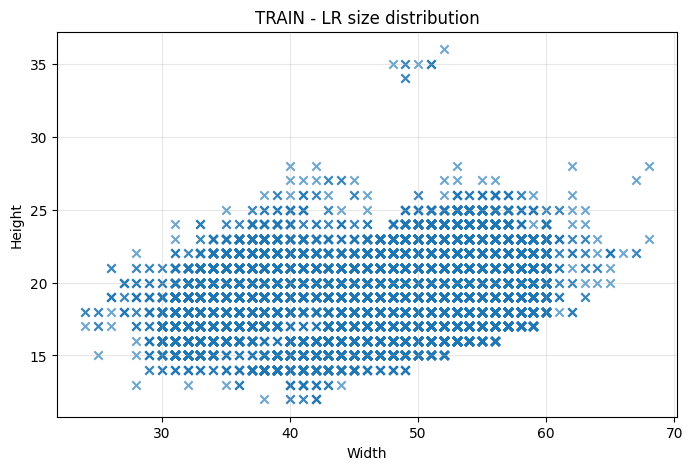

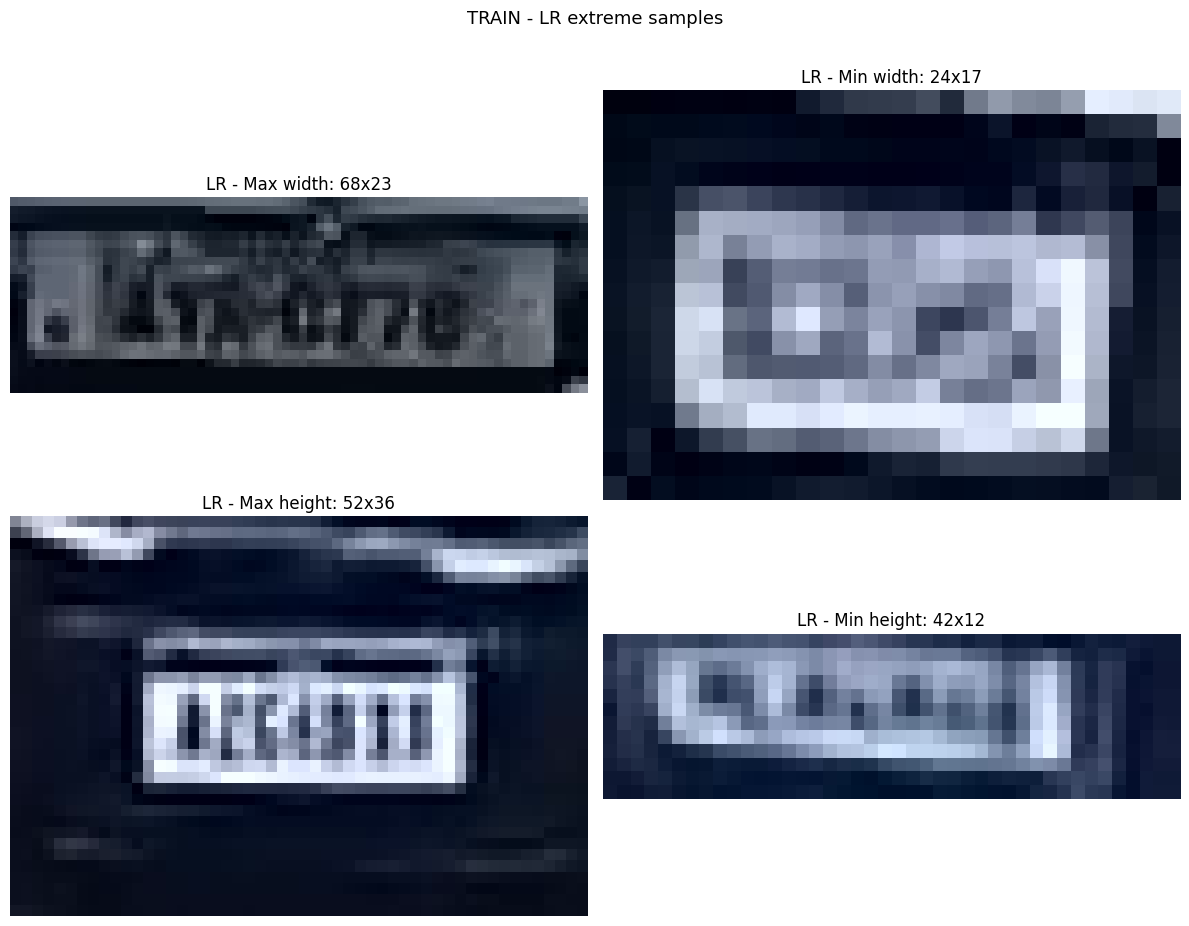

[HR] Max width sample : 164 x 55 | ../data\train\Scenario-B\Mercosur\track_15912\hr-001.jpg
[HR] Min width sample : 50 x 24 | ../data\train\Scenario-A\Mercosur\track_04051\hr-005.png
[HR] Max height sample: 156 x 61 | ../data\train\Scenario-B\Mercosur\track_15898\hr-001.jpg
[HR] Min height sample: 68 x 22 | ../data\train\Scenario-A\Brazilian\track_00103\hr-005.png


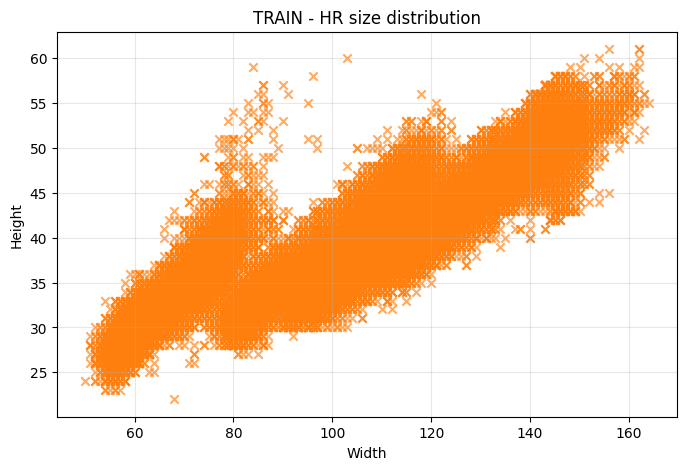

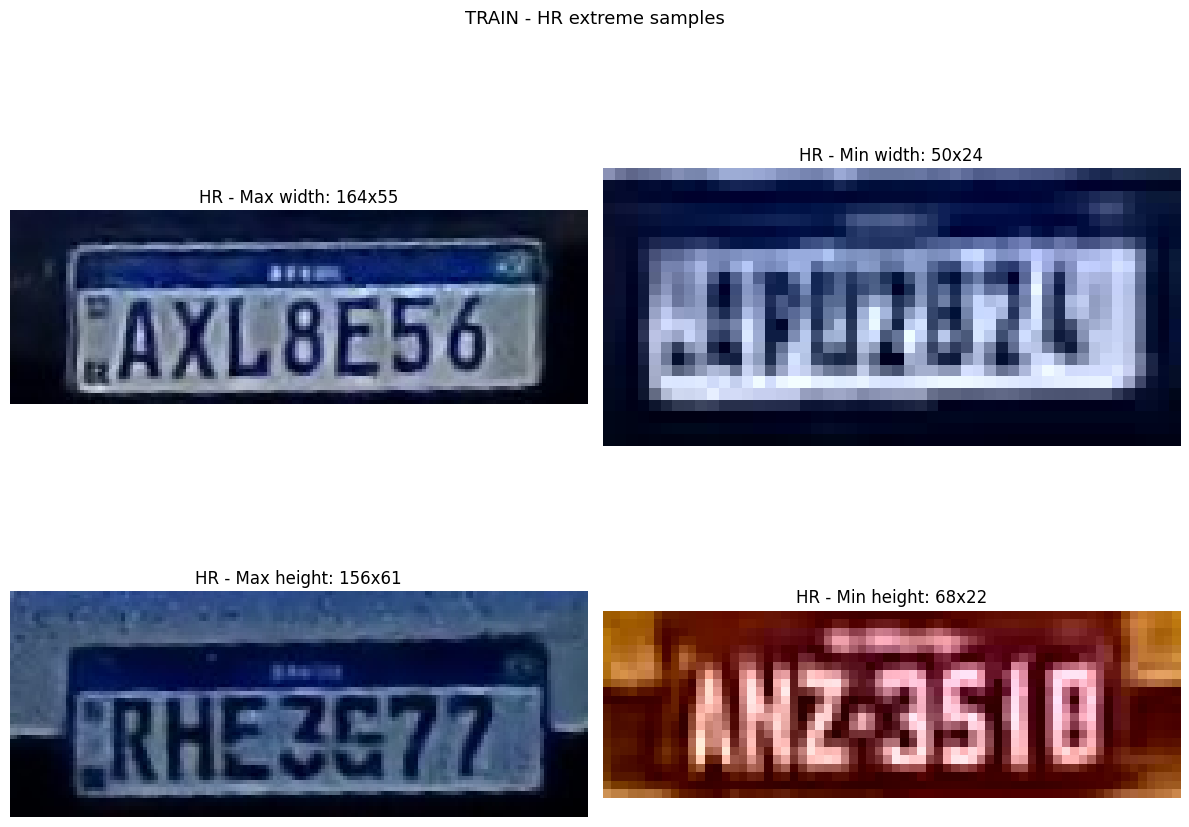

Preview 5/50000 samples for LR:
1. lr-001.png | plate='AVL5215' | chars={'a': 1, 'v': 1, 'l': 1, '5': 2, '2': 1, '1': 1}
2. lr-002.png | plate='AVL5215' | chars={'a': 1, 'v': 1, 'l': 1, '5': 2, '2': 1, '1': 1}
3. lr-003.png | plate='AVL5215' | chars={'a': 1, 'v': 1, 'l': 1, '5': 2, '2': 1, '1': 1}
4. lr-004.png | plate='AVL5215' | chars={'a': 1, 'v': 1, 'l': 1, '5': 2, '2': 1, '1': 1}
5. lr-005.png | plate='AVL5215' | chars={'a': 1, 'v': 1, 'l': 1, '5': 2, '2': 1, '1': 1}
Preview 5/50000 samples for HR:
1. hr-001.png | plate='AVL5215' | chars={'a': 1, 'v': 1, 'l': 1, '5': 2, '2': 1, '1': 1}
2. hr-002.png | plate='AVL5215' | chars={'a': 1, 'v': 1, 'l': 1, '5': 2, '2': 1, '1': 1}
3. hr-003.png | plate='AVL5215' | chars={'a': 1, 'v': 1, 'l': 1, '5': 2, '2': 1, '1': 1}
4. hr-004.png | plate='AVL5215' | chars={'a': 1, 'v': 1, 'l': 1, '5': 2, '2': 1, '1': 1}
5. hr-005.png | plate='AVL5215' | chars={'a': 1, 'v': 1, 'l': 1, '5': 2, '2': 1, '1': 1}
[train] ALL samples: 100000
[ALL] total valid 

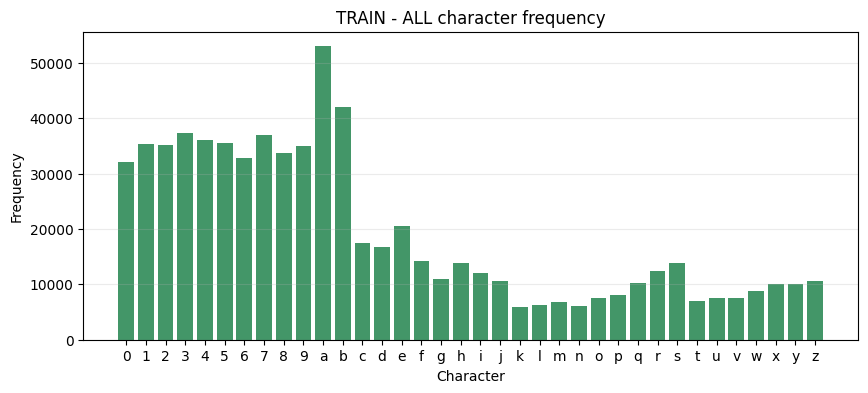

[train] LR max positions: 7
[LR] Position 1: {'A': 18840, 'B': 13220, 'C': 240, 'D': 450, 'E': 1035, 'F': 1290, 'G': 660, 'H': 175, 'I': 750, 'J': 250, 'K': 220, 'L': 280, 'M': 985, 'N': 255, 'O': 610, 'P': 1120, 'Q': 2470, 'R': 3160, 'S': 3760, 'T': 225, 'U': 5}
[LR] Position 2: {'A': 3455, 'B': 3490, 'C': 3985, 'D': 3315, 'E': 4305, 'F': 1515, 'G': 445, 'H': 2375, 'I': 850, 'J': 875, 'K': 850, 'L': 840, 'M': 695, 'N': 935, 'O': 1050, 'P': 1000, 'Q': 970, 'R': 1395, 'S': 1150, 'T': 1370, 'U': 1865, 'V': 1995, 'W': 2345, 'X': 2940, 'Y': 2860, 'Z': 3130}
[LR] Position 3: {'A': 1780, 'B': 1680, 'C': 1885, 'D': 2020, 'E': 2200, 'F': 1800, 'G': 1915, 'H': 2170, 'I': 1990, 'J': 1700, 'K': 1895, 'L': 2005, 'M': 1770, 'N': 1900, 'O': 2070, 'P': 1930, 'Q': 1650, 'R': 1680, 'S': 2015, 'T': 1870, 'U': 1865, 'V': 1750, 'W': 2045, 'X': 2090, 'Y': 2155, 'Z': 2170}
[LR] Position 4: {'0': 4330, '1': 4950, '2': 5090, '3': 5195, '4': 5605, '5': 5150, '6': 4710, '7': 5080, '8': 5065, '9': 4825}
[LR] Pos

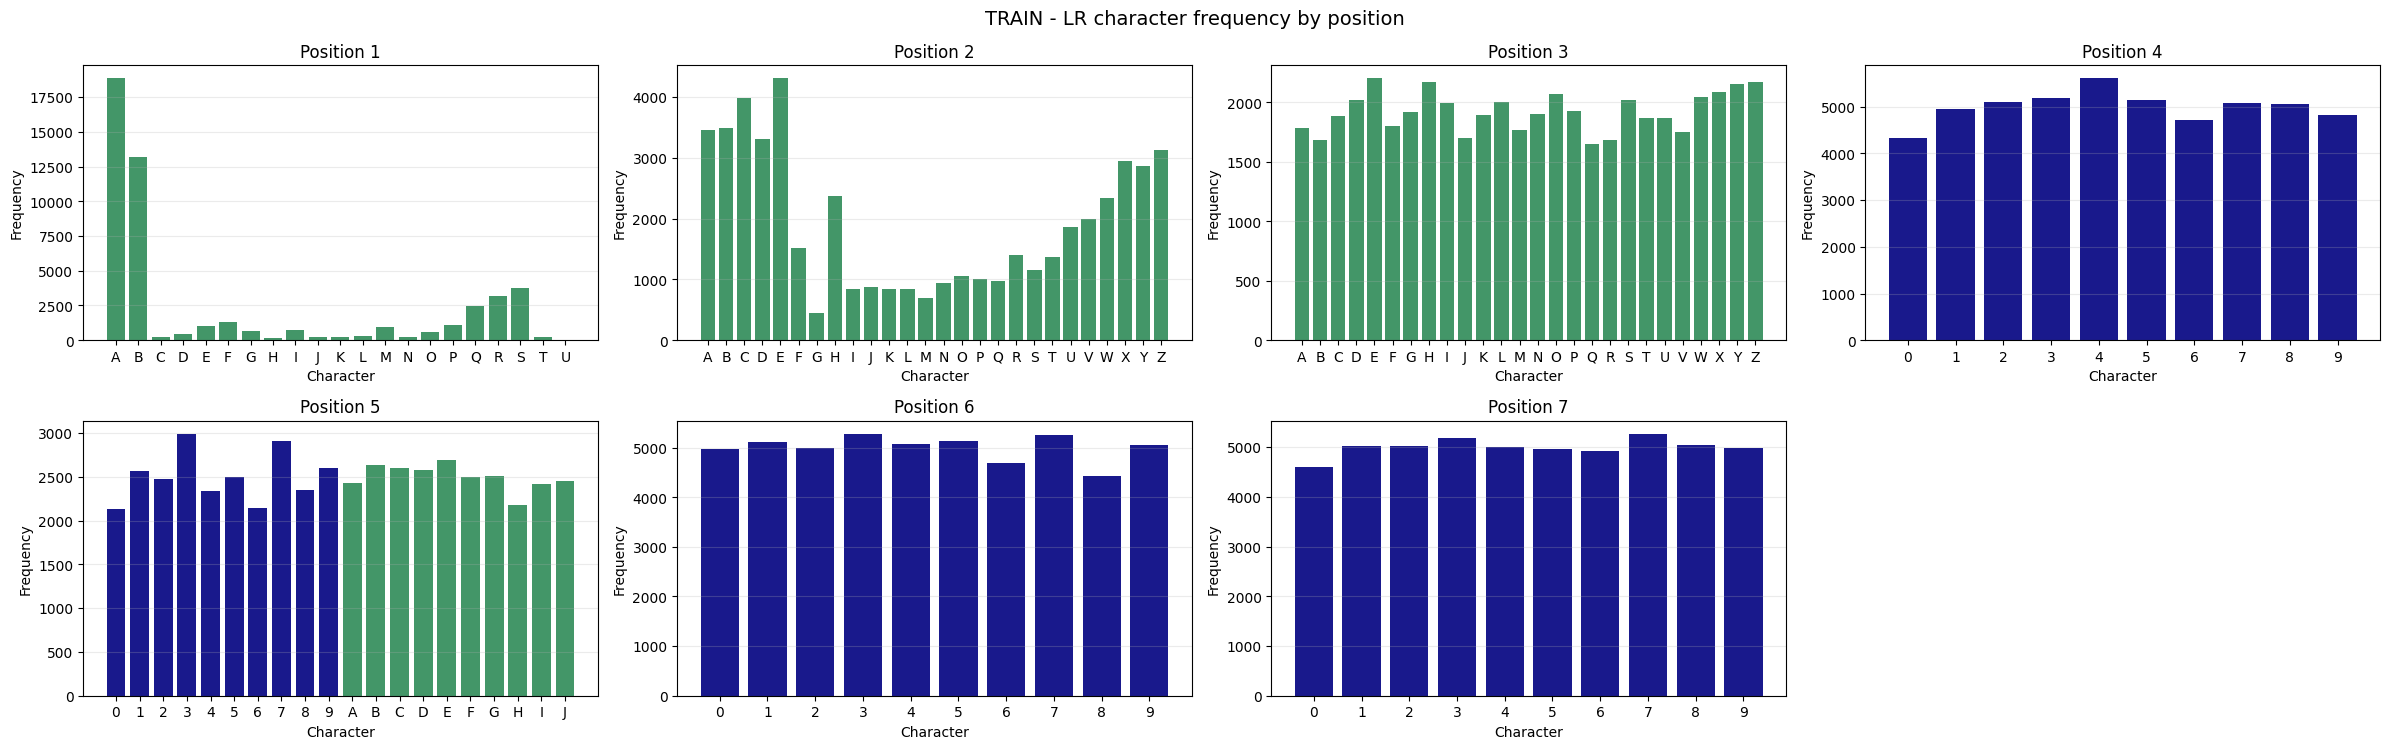

[train] HR max positions: 7
[HR] Position 1: {'A': 18840, 'B': 13220, 'C': 240, 'D': 450, 'E': 1035, 'F': 1290, 'G': 660, 'H': 175, 'I': 750, 'J': 250, 'K': 220, 'L': 280, 'M': 985, 'N': 255, 'O': 610, 'P': 1120, 'Q': 2470, 'R': 3160, 'S': 3760, 'T': 225, 'U': 5}
[HR] Position 2: {'A': 3455, 'B': 3490, 'C': 3985, 'D': 3315, 'E': 4305, 'F': 1515, 'G': 445, 'H': 2375, 'I': 850, 'J': 875, 'K': 850, 'L': 840, 'M': 695, 'N': 935, 'O': 1050, 'P': 1000, 'Q': 970, 'R': 1395, 'S': 1150, 'T': 1370, 'U': 1865, 'V': 1995, 'W': 2345, 'X': 2940, 'Y': 2860, 'Z': 3130}
[HR] Position 3: {'A': 1780, 'B': 1680, 'C': 1885, 'D': 2020, 'E': 2200, 'F': 1800, 'G': 1915, 'H': 2170, 'I': 1990, 'J': 1700, 'K': 1895, 'L': 2005, 'M': 1770, 'N': 1900, 'O': 2070, 'P': 1930, 'Q': 1650, 'R': 1680, 'S': 2015, 'T': 1870, 'U': 1865, 'V': 1750, 'W': 2045, 'X': 2090, 'Y': 2155, 'Z': 2170}
[HR] Position 4: {'0': 4330, '1': 4950, '2': 5090, '3': 5195, '4': 5605, '5': 5150, '6': 4710, '7': 5080, '8': 5065, '9': 4825}
[HR] Pos

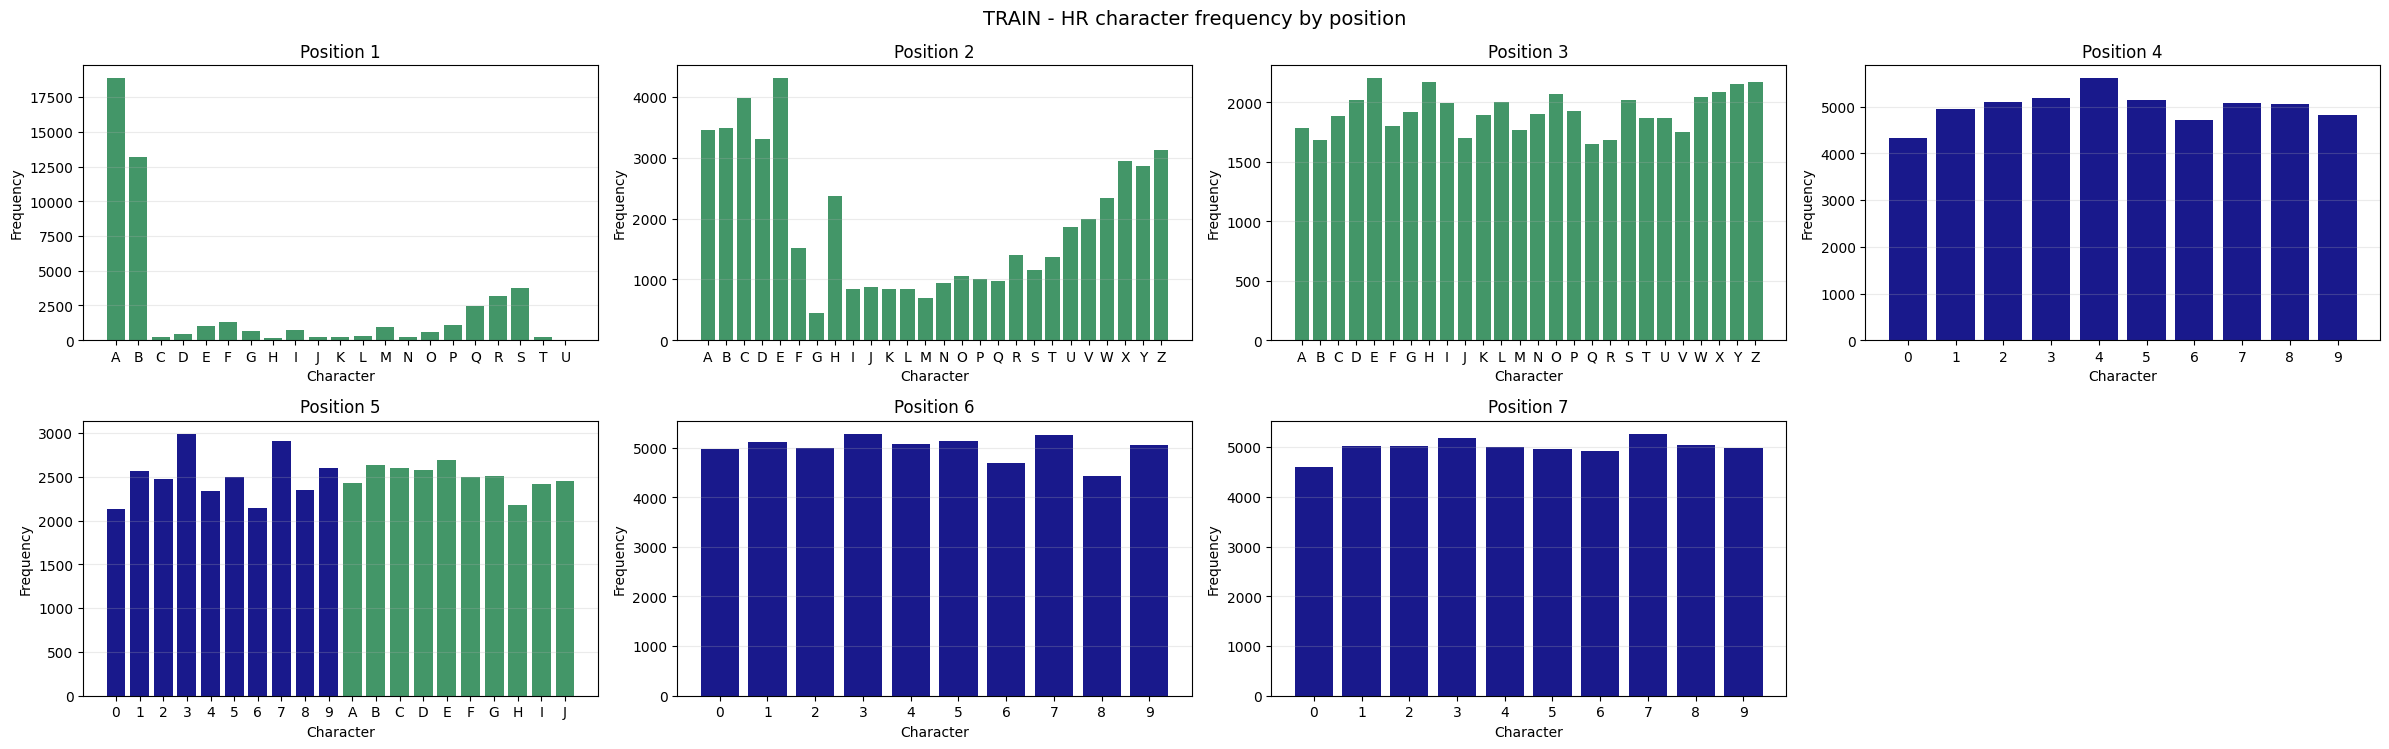

[Counter({'A': 18840,
          'B': 13220,
          'S': 3760,
          'R': 3160,
          'Q': 2470,
          'F': 1290,
          'P': 1120,
          'E': 1035,
          'M': 985,
          'I': 750,
          'G': 660,
          'O': 610,
          'D': 450,
          'L': 280,
          'N': 255,
          'J': 250,
          'C': 240,
          'T': 225,
          'K': 220,
          'H': 175,
          'U': 5}),
 Counter({'E': 4305,
          'C': 3985,
          'B': 3490,
          'A': 3455,
          'D': 3315,
          'Z': 3130,
          'X': 2940,
          'Y': 2860,
          'H': 2375,
          'W': 2345,
          'V': 1995,
          'U': 1865,
          'F': 1515,
          'R': 1395,
          'T': 1370,
          'S': 1150,
          'O': 1050,
          'P': 1000,
          'Q': 970,
          'N': 935,
          'J': 875,
          'I': 850,
          'K': 850,
          'L': 840,
          'M': 695,
          'G': 445}),
 Counter({'E': 2200,
         

In [5]:
# Visual cho tap train
Distribution_of_image_size(data_path, split='train')

lr_samples, hr_samples = get_char_counter_per_sample(data_path, split='train')
all_samples = lr_samples + hr_samples

preview_sample_char_counter(lr_samples, tag='LR', n=5)
preview_sample_char_counter(hr_samples, tag='HR', n=5)

summarize_char_counter(all_samples, tag='ALL', split='train')
summarize_char_by_position(lr_samples, tag='LR', split='train', n_cols=4)
summarize_char_by_position(hr_samples, tag='HR', split='train', n_cols=4)